# Bank Churn: Modeling
Baseline logistic regression on bankchurners_clean.csv, delivered as a threshold analysis.
EDA (Steps 1 to 13) in bankchurners_eda.ipynb confirmed top 5 features:
Total_Trans_Ct, Total_Ct_Chng_Q4_Q1, Total_Revolving_Bal,
Contacts_Count_12_mon, Months_Inactive_12_mon.
Churn rate 16.1%, class imbalance handled via class weights.
Fairness audit of this model: audit/fairness_audit.py.

## Split

Stratified 80/20, so the 16.1% churn rate is preserved in both halves.
`random_state=42` so the split is reproducible across reruns.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv('bankchurners_clean.csv', index_col='CLIENTNUM')

top5 = [
    'Total_Trans_Ct',
    'Total_Ct_Chng_Q4_Q1',
    'Total_Revolving_Bal',
    'Contacts_Count_12_mon',
    'Months_Inactive_12_mon'
]

X = df[top5]
y = df['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(8101, 5) (2026, 5)
0.1607208986544871 0.16041461006910168


## Scaling

The scaler is fit on the training set only, then applied to test. Fitting on
all the data first would let test-set statistics into training. That is a
quieter version of the same leakage problem the Naive Bayes columns caused in
the cleaning notebook.

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()               # create the scaling tool
X_train_scaled = scaler.fit_transform(X_train)  # learn from train + rewrite train
X_test_scaled  = scaler.transform(X_test)       # rewrite test using what was learned

print(X_train_scaled.mean(axis=0).round(2))   # check: every feature averages to 0
print(X_train_scaled.std(axis=0).round(2))    # check: every feature spread is 1

[-0. -0.  0.  0.  0.]
[1. 1. 1. 1. 1.]


## Class weighting rather than SMOTE

At 16% positives, an unweighted model maximises accuracy by predicting that
nobody churns. `class_weight='balanced'` reweights errors inversely to class
frequency, roughly 5.2x on churners, inside the loss function.

I chose it over SMOTE because it adds no synthetic rows and no new
hyperparameters, so the pipeline stays auditable. I did not run a head to head
against SMOTE, and that is listed under limitations rather than claimed as a
tested result.

In [3]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Model trained")
print("Coefficients:", dict(zip(top5, model.coef_[0].round(3))))

Model trained
Coefficients: {'Total_Trans_Ct': np.float64(-1.355), 'Total_Ct_Chng_Q4_Q1': np.float64(-0.584), 'Total_Revolving_Bal': np.float64(-0.634), 'Contacts_Count_12_mon': np.float64(0.498), 'Months_Inactive_12_mon': np.float64(0.5)}


In [4]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("First 10 predictions:", y_pred[:10])
print("First 10 probabilities:", y_proba[:10].round(3))
print("Predicted churn rate on test:", y_pred.mean().round(3))

First 10 predictions: [0 0 1 0 0 0 0 0 1 0]
First 10 probabilities: [0.111 0.023 0.651 0.027 0.191 0.053 0.107 0.063 0.727 0.166]
Predicted churn rate on test: 0.296


## Confusion matrix at the default threshold

Read this as the 0.5 case only. The threshold sweep at the bottom of the
notebook is the number that actually matters, because 0.5 is an arbitrary
default rather than a business decision.

[[1350  351]
 [  76  249]]


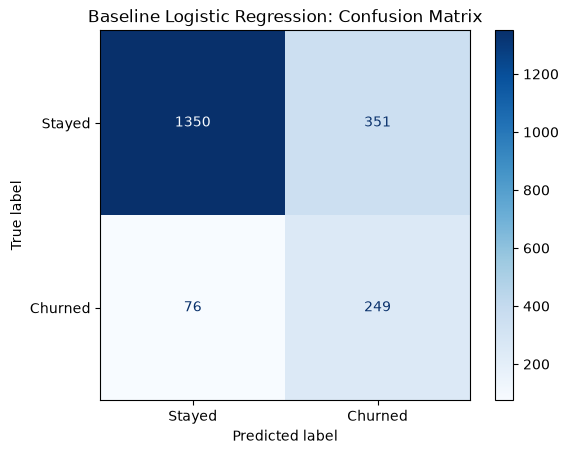

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(cm)

ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned']).plot(cmap='Blues')
plt.title('Baseline Logistic Regression: Confusion Matrix')
plt.show()

## Recall first

A missed churner costs a customer relationship. A false alarm costs one
retention call. Recall is therefore the metric to optimise, with precision
watched as the cost side of that choice.

In [6]:
from sklearn.metrics import recall_score, precision_score, f1_score

recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Recall:    {recall:.3f}")
print(f"Precision: {precision:.3f}")
print(f"F1:        {f1:.3f}")

Recall:    0.766
Precision: 0.415
F1:        0.538


## ROC-AUC

Threshold independent, so this measures how well the model ranks customers by
risk rather than how it performs at any particular cut point.

In [7]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 0.870


## Threshold as a capacity decision

The model outputs probabilities. Where to cut them is a question about how many
customers the retention team can actually contact, not a modelling question.

At 0.3 the team catches 89% of churners but works a list of 906. At 0.7 the
list is 333 and nearly 40% of churners are missed.

This sweep is computed on the test set, which is mildly optimistic. A
validation split would be cleaner, and that is noted in the README.

In [8]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print(f"{'Threshold':<10}{'Recall':<10}{'Precision':<10}{'Flagged':<10}")
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    r = recall_score(y_test, y_pred_t)
    p = precision_score(y_test, y_pred_t)
    n = y_pred_t.sum()
    print(f"{t:<10}{r:<10.3f}{p:<10.3f}{n:<10}")

Threshold Recall    Precision Flagged   
0.3       0.889     0.319     906       
0.4       0.822     0.364     733       
0.5       0.766     0.415     600       
0.6       0.717     0.511     456       
0.7       0.603     0.589     333       
